In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version in PyTorch: {torch.version.cuda}")
import torchvision
from torchvision.transforms import v2

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version in PyTorch: 12.1


In [4]:
transform= v2.Compose([#compose acts a wrapper that chains multiple transformation together
    v2.ToImage(),#it converts the incoming data into torch.tensor
    
    v2.ToDtype(torch.float32,scale= True),#first coverts the tensors into float32 and it scales it down by dividing it by 255 and bring in the range of 0.0-1.0 which ensures the training stability
    
    v2.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])#we do normalization to make sure that only one more than one pixels are not dominating and 
#it also reduces the training time and makes the model more efficient.
#After normalization now the value of the tensor shifts from -1.0 to 1.0 

batch_size= 4
train_set= torchvision.datasets.CIFAR10(root= './data',train= True,download= True,transform= transform)
train_loader= torch.utils.data.DataLoader(train_set, batch_size= batch_size, shuffle= True,num_workers= 2)#the num_workers helps the model work in parallel just like how multithreading works
test_set= torchvision.datasets.CIFAR10(root= './data',train= False,download= True, transform= transform)
test_loader= torch.utils.data.DataLoader(test_set,batch_size= batch_size, shuffle= False,num_workers= 2)

classes= ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

Files already downloaded and verified
Files already downloaded and verified


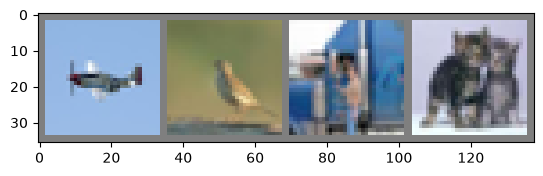

plane bird  truck cat  


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img= img*0.5+0.5#reversing the normalization process by multiplying img by 0.5(standard deviation) and adding it by 0.5(mean)
    npimg= img.numpy()#converting img into numpy array to display the image as matplotlib only supports numpy array but our img is in torch.tensor rn 
    plt.imshow(np.transpose(npimg,(1,2,0)))#rearrange the dimensions from pytorch's channel first format(channel,height,width) to matplotlib's channel last format(height,width,channel)
    plt.show()

dataiter= iter(train_loader)#creates a iterator(iterator is like a pointer that moves through a collection of items ,picking them 1 by 1) for the trainloader to allow sequential batch fetching
images,labels= next(dataiter)#fetches the next batch of images and label from the dataiter

imshow(torchvision.utils.make_grid(images))#combines the batch of imgs into single grid for visualization

print(' '.join(f'{classes[labels[j]]:5s}'for j in range(batch_size)))#retrives and prints the labels for the batch of the img and joins by spaces 
    


Neural Net

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1= nn.Conv2d(3,6,5)
        self.pool= nn.MaxPool2d(2,2)
        self.conv2= nn.Conv2d(6,16,5)
        self.fc1= nn.Linear(16*5*5,120)
        self.fc2= nn.Linear(120,84)
        self.fc3= nn.Linear(84,10)
    def forward(self,x):
        x= self.pool(F.relu(self.conv1(x)))
        x= self.pool(F.relu(self.conv2(x)))
        x= torch.flatten(x,1)#flattens all dim expect batch
        x= F.relu(self.fc1(x))
        x= F.relu(self.fc2(x))
        x= self.fc3(x)
        return x
net= Net()

Defining Loss Function

In [8]:
import torch.optim as optim
cost= nn.CrossEntropyLoss()
optimizer= optim.SGD(net.parameters(),lr= 0.001,momentum= 0.9)

Training the Network

In [9]:
# Replace the torch.accelerator line with this:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)
for epoch in range(2):
    running_loss= 0
    for i,data in enumerate(train_loader,0):
        input,labels= data[0].to(device),data[1].to(device)#gets the input and the data is list of [input,labels]

        optimizer.zero_grad()# making all the gradients of the parameters 0

        output= net(input)
        Loss= cost(output,labels)
        Loss.backward()
        optimizer.step()

        running_loss+= Loss.item()

        if i%2000 == 1999:
            print(f'[{epoch+1},{i+1:5d}],Loss:{running_loss/2000:.3f}')
            running_loss= 0.0
print('Training Finished Big dawg')

[1, 2000],Loss:2.184
[1, 4000],Loss:1.882
[1, 6000],Loss:1.703
[1, 8000],Loss:1.600
[1,10000],Loss:1.534
[1,12000],Loss:1.458
[2, 2000],Loss:1.387
[2, 4000],Loss:1.376
[2, 6000],Loss:1.322
[2, 8000],Loss:1.293
[2,10000],Loss:1.257
[2,12000],Loss:1.251
Training Finished Big dawg


Saving the model

In [10]:
PATH= './cifar_net.pt'
torch.save(net.state_dict(),PATH)

Testing the network

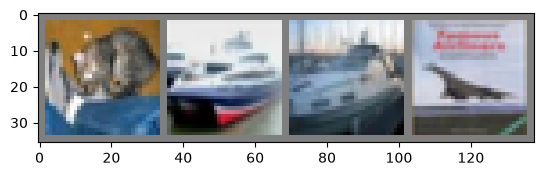

The objects in the imgs are : cat   ship  ship  plane


In [11]:
dataiter= iter(test_loader)
images,labels= next(dataiter)
imshow(torchvision.utils.make_grid(images))
print('The objects in the imgs are :',' '.join(f'{classes[labels[j]]:5s}'for j in range(batch_size)))

In [13]:
correct= 0
total= 0 
with torch.no_grad():
    for data in test_loader:
        images,labels= data[0].to(device),data[1].to(device)
        output= net(images)
        _,predict= torch.max(output,1)
        total+= labels.size(0)
        correct+= (predict==labels).sum().item()
print(f"The Accuracy of the network on 10000 imgs is: {100*correct//total}%")

The Accuracy of the network on 10000 imgs is: 55%


In [14]:
correct_pred= {classname:0 for classname in classes }
total_pred= {classname:0 for classname in classes}

with torch.no_grad():
    for data in test_loader:
        images,labels= data[0].to(device),data[1].to(device)
        output= net(images)
        _,predictions= torch.max(output,1)
        #colllecting correct prediction for each class
        for predictions,labels in zip(predictions,labels):
            if labels == predictions:
                correct_pred[classes[labels]]+= 1

            total_pred[classes[labels]]+=1
for classname,correct_count in correct_pred.items():
    accuracy= 100*float(correct_count)//total_pred[classname]
    print(f'The accuracy for class: {classname:5s} is {accuracy:.1f}%')

The accuracy for class: plane is 61.0%
The accuracy for class: car   is 64.0%
The accuracy for class: bird  is 43.0%
The accuracy for class: cat   is 36.0%
The accuracy for class: deer  is 25.0%
The accuracy for class: dog   is 50.0%
The accuracy for class: frog  is 83.0%
The accuracy for class: horse is 58.0%
The accuracy for class: ship  is 79.0%
The accuracy for class: truck is 52.0%
